# GameTheory-6c : Jeux Répétés et Théorème Folk (Folk Theorem)

**Navigation** : [<< 6-EvolutionTrust](GameTheory-6-EvolutionTrust.ipynb) | [Index](README.md) | [7-ExtensiveForm >>](GameTheory-7-ExtensiveForm.ipynb)

Ce notebook est le compagnon **formel** de [GameTheory-6-EvolutionTrust](GameTheory-6-EvolutionTrust.ipynb). Là, GT-6 étudiait de façon **empirique** comment la coopération émerge dans des tournois itérés (Axelrod, dynamique du réplicateur). Ici, nous établissons le résultat **théorique** qui l'explique : pourquoi et à quelles conditions la coopération est un équilibre crédible dans un jeu répété infini.


## Objectifs d'apprentissage

À l'issue de ce notebook, vous saurez :
1. Distinguer un jeu répété **fini** (où la coopération s'effondre par induction vers l'arrière) d'un jeu répété **infini** (où elle peut être soutenable).
2. Formaliser le **facteur d'escompte** $\delta$ et écrire la valeur actualisée d'un flux de gains comme série géométrique.
3. Établir la **condition de crédibilité** du grim trigger : $\delta \ge (T-R)/(T-P)$.
4. Énoncer et illustrer le **Folk Theorem** : tout paiement faisable et individuellement rationnel est soutenable comme équilibre parfait en sous-jeux (SPNE) pour des joueurs assez patients.

### Prérequis
- [GameTheory-6-EvolutionTrust](GameTheory-6-EvolutionTrust.ipynb) (Dilemme du Prisonnier, tit-for-tat, intuition de la coopération itérée).
- Algèbre linéaire et séries géométriques de base.

### Durée estimée : 45 minutes


## 1. Le jeu étape (Dilemme du Prisonnier)

On reprend le Dilemme du Prisonnier de GT-6 (convention Axelrod) :

| | Coopérer (C) | Défecter (D) |
|---|---|---|
| **Coopérer (C)** | R=3, R=3 | S=0, T=5 |
| **Défecter (D)** | T=5, S=0 | P=1, P=1 |

avec **T** (tentation) > **R** (récompense) > **P** (punition) > **S** (dupe), et la condition $2R > T+S$. L'unique équilibre de Nash du jeu étape est **(D, D)** (paiement P=1), alors que la coopération mutuelle (R=3) est strictement Pareto-supérieure : c'est le dilemme.


In [1]:
import numpy as np

# Matrice des gains du Dilemme du Prisonnier (lignes = joueur 1, colonnes = joueur 2)
# Ordre des actions : Cooperer (0), Defecter (1)
T, R, P, S = 5.0, 3.0, 1.0, 0.0   # Axelrod convention
A1 = np.array([[R, S],   # joueur 1 coopere
               [T, P]])  # joueur 1 defecte
A2 = np.array([[R, T],   # joueur 2 coopere
               [S, P]])  # joueur 2 defecte

print('Gain joueur 1 (lignes=J1, colonnes=J2):')
print(A1)
print()
print('Verif des inegalites du DP : T>R>P>S :', T > R > P > S)
print('Verif 2R > T+S :', 2*R > T+S, '(2R=%g, T+S=%g)' % (2*R, T+S))
print('Equilibre de Nash du jeu etape : (D,D) -> paiement P =', P)
print('Pareto-optimum cooperatif : (C,C) -> paiement R =', R)


Gain joueur 1 (lignes=J1, colonnes=J2):
[[3. 0.]
 [5. 1.]]

Verif des inegalites du DP : T>R>P>S : True
Verif 2R > T+S : True (2R=6, T+S=5)
Equilibre de Nash du jeu etape : (D,D) -> paiement P = 1.0
Pareto-optimum cooperatif : (C,C) -> paiement R = 3.0


## 2. Horizon fini : l'effondrement inévitable

Considérons une répétition **finie** de N tours. On résout par **induction vers l'arrière** : au dernier tour N, il n'y a pas d'avenir à menacer, donc chaque joueur défecte (c'est l'équilibre du jeu étape). Sachant cela au tour N-1, aucune menace future n'est crédible, donc on défecte aussi. Et ainsi de suite jusqu'au tour 1 : **(D, D) à chaque tour**.

> **Théorème (effondrement de l'horizon fini)** : dans tout jeu répété un nombre **connu** et **fini** de fois, le seul SPNE est la défection perpétuelle, pourvu que le jeu étape ait un unique équilibre de Nash.

La coopération exige donc un horizon **infini** (ou une probabilité positive de continuer à chaque tour).


In [2]:
# Illustration : dans un jeu fini, la defection perpetuelle est l'unique SPNE.
# Valeurs actualisees (delta=1, pas d'escompte) sur N tours :

N = 10
payoff_defect_always = P * N          # (D,D) chaque tour
payoff_cooperate_if_possible = R * N  # (C,C) chaque tour, irrealiste en horizon fini
print('Horizon fini N =', N, 'tours (delta=1)')
print('  Paiement SPNE (D,D)xN   = %.1f' % payoff_defect_always)
print('  Paiement coop. fictif   = %.1f (NON credible : effondre par induction)' % payoff_cooperate_if_possible)
print()
print('Conclusion : en horizon fini, le SPNE = defaction, paiement total = P*N = %.1f' % payoff_defect_always)
print('La cooperation (R=%.1f > P=%.1f) exige un horizon INFINI.' % (R, P))


Horizon fini N = 10 tours (delta=1)
  Paiement SPNE (D,D)xN   = 10.0
  Paiement coop. fictif   = 30.0 (NON credible : effondre par induction)

Conclusion : en horizon fini, le SPNE = defaction, paiement total = P*N = 10.0
La cooperation (R=3.0 > P=1.0) exige un horizon INFINI.


## 3. Horizon infini et facteur d'escompte

On suppose maintenant que le jeu se répète **infiniment**, avec un facteur d'escompte $\delta \in [0,1[$ ($1$ unité de gain demain vaut $\delta$ aujourd'hui ; $\delta$ proche de 1 = joueur patient). Le paiement total d'un joueur est la **somme actualisée** :

$$ V = u_0 + \delta u_1 + \delta^2 u_2 + \cdots = \sum_{t=0}^{\infty} \delta^t u_t $$

Pour un flux **constant** de gains $g$ chaque tour, la série géométrique se simplifie en :

$$ V(g) = \frac{g}{1 - \delta} $$

($\delta < 1$ garantit la convergence). C'est cette forme fermée qui rend l'analyse des jeux répétés infinis tractable.


In [3]:
# Verif numerique de la serie geometrique g/(1-delta)
def flux_geom(g, delta, terms=2000):
    """Somme actualisee d'un flux constant g sur 'terms' tours."""
    return sum((delta**t) * g for t in range(terms))

for delta in [0.3, 0.5, 0.7, 0.9, 0.99]:
    closed = R / (1 - delta)
    approx = flux_geom(R, delta)
    print('delta=%-5s : formule g/(1-d)=%10.4f | somme tronquee=%10.4f' % (delta, closed, approx))
print()
print('Les deux colonnes coincident : la serie converge vers g/(1-delta).')


delta=0.3   : formule g/(1-d)=    4.2857 | somme tronquee=    4.2857
delta=0.5   : formule g/(1-d)=    6.0000 | somme tronquee=    6.0000
delta=0.7   : formule g/(1-d)=   10.0000 | somme tronquee=   10.0000
delta=0.9   : formule g/(1-d)=   30.0000 | somme tronquee=   30.0000
delta=0.99  : formule g/(1-d)=  300.0000 | somme tronquee=  300.0000

Les deux colonnes coincident : la serie converge vers g/(1-delta).


## 4. Le grim trigger et sa condition de crédibilité

La stratégie du **grim trigger** (le vengeur implacable) est : *coopérer tant que l'autre a coopéré, mais si l'autre défecte une seule fois, défecter pour toujours*. C'est une menace maximale, **irréversible**.

Comparons, du point de vue du joueur 1 (admettant que le joueur 2 joue grim trigger) :

- **Coopérer toujours** : paiement $R$ chaque tour $\Rightarrow V_C = R/(1-\delta)$.
- **Défecter une fois** (gain $T$ au tour de la défection), puis le joueur 2 applique grim trigger $\Rightarrow$ punition $P$ chaque tour ensuite $\Rightarrow V_D = T + \delta P/(1-\delta)$.

La coopération est **soutenable** (incitation à ne pas dévier) ssi $V_C \ge V_D$ :

$$ \frac{R}{1-\delta} \ge T + \frac{\delta P}{1-\delta} \quad\Longleftrightarrow\quad \delta \ge \frac{T - R}{T - P} $$

**Application numérique** (cellule suivante) : pour le DP canonique $T=5, R=3, P=1$, le seuil vaut $\delta^* = (5-3)/(5-1) = 0{,}5$. En dessous (ex. $\delta=0{,}3$ : $V_C \approx 4{,}29 < V_D \approx 5{,}43$), la tentation l'emporte et la défection est rationnelle ; au-dessus (ex. $\delta=0{,}7$ : $V_C = 10 > V_D \approx 7{,}33$), la coopération est crédible. Exactement au seuil $\delta^*=0{,}5$, les joueurs sont indifférents ($V_C = V_D = 6$).


In [4]:
# Derivation numerique de la condition de credibilite
# V_C = R/(1-d), V_D = T + d*P/(1-d). Cooperation soutenable si V_C >= V_D.

def VC(delta): return R / (1 - delta)
def VD(delta): return T + delta * P / (1 - delta)

# Seuil exact (T-R)/(T-P)
delta_star = (T - R) / (T - P)
print('Stage game : T=%g R=%g P=%g S=%g' % (T, R, P, S))
print('Seuil de credibilite delta* = (T-R)/(T-P) = (%g-%g)/(%g-%g) = %.4f' % (T, R, T, P, delta_star))
print()
print('%-8s %-12s %-12s %s' % ('delta', 'V_C(coop)', 'V_D(deviat)', 'Coop. soutenable?'))
for delta in [0.30, 0.40, 0.50, 0.60, 0.70]:
    vc, vd = VC(delta), VD(delta)
    flag = 'OUI' if vc >= vd else 'NON'
    print('%-8.2f %-12.4f %-12.4f %s' % (delta, vc, vd, flag))
print()
print('Verification au seuil delta*=0.5 : V_C=%.4f, V_D=%.4f (indifference)' % (VC(delta_star), VD(delta_star)))


Stage game : T=5 R=3 P=1 S=0
Seuil de credibilite delta* = (T-R)/(T-P) = (5-3)/(5-1) = 0.5000

delta    V_C(coop)    V_D(deviat)  Coop. soutenable?
0.30     4.2857       5.4286       NON
0.40     5.0000       5.6667       NON
0.50     6.0000       6.0000       OUI
0.60     7.5000       6.5000       OUI
0.70     10.0000      7.3333       OUI

Verification au seuil delta*=0.5 : V_C=6.0000, V_D=6.0000 (indifference)


## 5. Tit-for-tat vs grim trigger

Le **tit-for-tat** (TFT, œil pour œil : coopérer au tour 1, puis copier le coup précédent de l'adversaire) est plus **clément** que le grim trigger : il pardonne après une seule coopération revenue. Mais sa clémence a un coût : la condition de crédibilité est plus stricte.

- TFT vs TFT : coopération perpétuelle, paiement $R/(1-\delta)$.
- Déviation vs TFT (défecter, puis TFT punit un tour puis pardonne) : paiement $T + \delta S + \delta^2 R/(1-\delta)$ (on gagne $T$ en déviant, $S$ au tour de contre-punition, puis retour à $R$).

La coopération sous TFT est soutenable ssi $R/(1-\delta) \ge T + \delta S + \delta^2 R/(1-\delta)$, soit un seuil plus élevé car la punition est plus légère.


In [5]:
# Comparaison des seuils : grim trigger (punition dure) vs tit-for-tat (punition legere)
def VC2(delta): return R / (1 - delta)
def VD_grim(delta): return T + delta * P / (1 - delta)
def VD_tft(delta):  return T + delta * S + (delta**2) * R / (1 - delta)  # TFT punit 1 tour puis pardonne

# Seuil grim trigger (exact) et TFT (numerique)
deltas = np.linspace(0.01, 0.99, 10000)
delta_grim = (T - R) / (T - P)
tft_ok = VC2(deltas) >= VD_tft(deltas)
delta_tft = deltas[np.argmax(tft_ok)] if tft_ok.any() else float('nan')

print('Seuil grim trigger : delta* = %.4f  (punition P a jamais)' % delta_grim)
print('Seuil tit-for-tat  : delta* = %.4f  (punition legere, pardonne)' % delta_tft)
print()
print('Conclusion : grim trigger soutient la cooperation pour delta >= %.3f' % delta_grim)
print('             tit-for-tat exige  delta >= %.3f (PLUS patient requis)' % delta_tft)
print('Punition plus dure => cooperation plus facile a soutenir (folk theorem intuition).')


Seuil grim trigger : delta* = 0.5000  (punition P a jamais)
Seuil tit-for-tat  : delta* = 0.6668  (punition legere, pardonne)

Conclusion : grim trigger soutient la cooperation pour delta >= 0.500
             tit-for-tat exige  delta >= 0.667 (PLUS patient requis)
Punition plus dure => cooperation plus facile a soutenir (folk theorem intuition).


## 6. Le Folk Theorem

Le grim trigger montre qu'**une** paire de paiements coopératifs $(R,R)$ est soutenable. Le **Folk Theorem** généralise considérablement ce résultat.

> **Folk Theorem (version jeux répétés infinis, joueurs patients)** : Soit $v = (v_1, v_2)$ un vecteur de paiements **faisable** (combinaison convexe des paiements du jeu étape) et **individuellement rationnel** ($v_i \ge \underline{v}_i$, le paiement de minimax du joueur $i$). Alors il existe $\underline{\delta} < 1$ tel que pour tout $\delta \ge \underline{\delta}$, $v$ est soutenable comme paiement d'un SPNE du jeu répété infini.

**Interprétation** : pour des joueurs assez patients ($\delta \to 1$), **presque tout** résultat est crédible comme équilibre. C'est à la fois la puissance (la coopération est robuste) et la faiblesse (le concept d'équilibre perd son pouvoir prédictif : tout peut être un équilibre).

Le **paiement de minimax** $\underline{v}_i$ est le pire que les autres puissent infliger au joueur $i$ (dans le DP symétrique, c'est $P=1$).


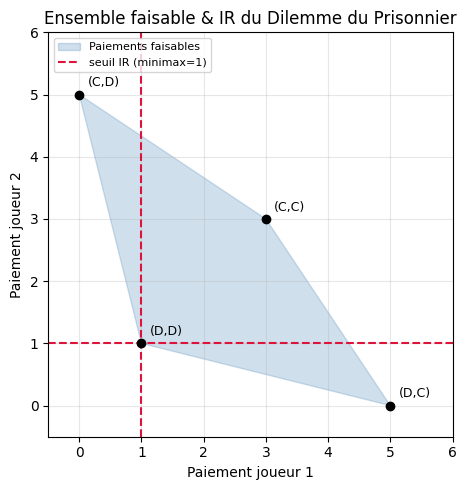

La region faisable & IR (au-dessus et a droite des pointilles) = ensemble des paiements
soutenables comme SPNE pour delta assez proche de 1 (Folk Theorem).


In [6]:
# Illustration : ensemble des paiements faisables et individuellement rationnels (IR)
# du DP. Les 4 paiements d'issues : (C,C)=(R,R), (C,D)=(S,T), (D,C)=(T,S), (D,D)=(P,P).
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

issues = np.array([[P, P], [T, S], [R, R], [S, T]])   # enveloppe convexe des 4 issues (ordre CCW, evite polygone auto-secant)
minimax = P   # DP symetrique

fig, ax = plt.subplots(figsize=(6, 5))
ax.add_patch(Polygon(issues, closed=True, alpha=0.25, color='steelblue', label='Paiements faisables'))
ax.axvline(minimax, color='crimson', ls='--')
ax.axhline(minimax, color='crimson', ls='--', label='seuil IR (minimax=%g)' % minimax)
labels = {'(C,C)':(R,R), '(D,D)':(P,P), '(C,D)':(S,T), '(D,C)':(T,S)}
for lab,(x,y) in labels.items():
    ax.plot(x, y, 'ko', ms=6)
    ax.annotate(lab, (x,y), textcoords='offset points', xytext=(6,6), fontsize=9)
ax.set_xlim(-0.5, 6); ax.set_ylim(-0.5, 6)
ax.set_xlabel('Paiement joueur 1'); ax.set_ylabel('Paiement joueur 2')
ax.set_title('Ensemble faisable & IR du Dilemme du Prisonnier')
ax.legend(loc='upper left', fontsize=8); ax.set_aspect('equal'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('La region faisable & IR (au-dessus et a droite des pointilles) = ensemble des paiements')
print('soutenables comme SPNE pour delta assez proche de 1 (Folk Theorem).')


### Interprétation : la coopération comme cas particulier

Le paiement coopératif $(R,R)=(3,3)$ n'est qu'**un point** dans l'ensemble faisable & IR. Le Folk Theorem dit qu'il est soutenable (ce que le grim trigger démontre explicitement), mais aussi que beaucoup d'autres conventions le sont. C'est pourquoi, dans les tournois d'Axelrod de GT-6, plusieurs stratégies co-existent et performent bien : la théorie n'en exclut aucune par avance dès que $\delta$ est assez grand.

La cellule de comparaison l'illustre : le **grim trigger** (punition irréversible) soutient la coopération dès $\delta \ge 0{,}5$, alors que le **tit-for-tat** (punition légère d'un tour, qui pardonne) exige $\delta \ge 0{,}667$. Plus la punition est dure, plus le seuil de patience requis est bas : c'est l'intuition centrale qui se généralise dans le Folk Theorem.


## Exercice 1 : Sensibilité au facteur d'escompte

Reprenez le grim trigger avec un DP modifié : $T=6, R=4, P=2, S=0$.

**Indice :** calculez le nouveau seuil $\delta^*=(T-R)/(T-P)$ et comparez-le au DP canonique (0,5). La tentation plus forte rend-elle la coopération plus ou moins facile à soutenir ?

**Étape 1 :** vérifier les inégalités du DP et 2R > T+S.
**Étape 2 :** calculer le seuil analytiquement.


In [7]:
# Exercice 1 a completer
T_e, R_e, P_e, S_e = 6.0, 4.0, 2.0, 0.0
delta_star_e = None  # TODO etudiant : calculer le seuil (T-R)/(T-P)
print('Seuil a determiner :', delta_star_e)


Seuil a determiner : None


## Exercice 2 : Une punition limitée (N-périodes)

Considérons une stratégie **punition limitée** : si l'autre défecte, on le punit en défectant pendant exactement $N$ tours, puis on revient à la coopération (à la différence du grim trigger qui est irréversible).

**Indice :** plus $N$ est petit, plus la punition est légère, donc plus $\delta$ requis est élevé. Écrivez $V_D$ pour cette stratégie.

**Étape 1 :** exprimer le paiement de déviation (T, puis N tours à P, puis retour à R/(1-d)).
**Étape 2 :** pour N=2, trouver numériquement le seuil et le comparer au grim trigger.


In [8]:
# Exercice 2 a completer
def VD_limited(delta, N):
    result = None  # TODO etudiant : T + sum_{k=1}^{N} delta^k * P + delta^{N+1} * R/(1-delta)
    return result
print('A completer pour N=2 :', VD_limited(0.5, 2))


A completer pour N=2 : None


## Exercice 3 : Au-delà du DP - jeu de la poule (Chicken)

Le **jeu de la poule** a pour gains $T=4, R=3, P=0, S=1$ (notez $P < S$ : s'écraser contre un dur est pire que les deux s'écrasent). Ce n'est PAS un DP.

**Indice :** identifiez les deux équilibres de Nash purs de ce jeu étape. Que dit le Folk Theorem sur les paiements soutenables dans sa version infinie ?

**Étape 1 :** trouver les équilibres de Nash purs (matrice 2x2).
**Étape 2 :** calculer le paiement de minimax et l'ensemble faisable & IR.


In [9]:
# Exercice 3 a completer
# Matrice du jeu de la poule : a analyser
A1_chicken = np.array([[3, 1], [4, 0]])  # TODO etudiant : identifier les equilibres de Nash
A2_chicken = np.array([[3, 4], [1, 0]])
print('Equilibres de Nash pures a identifier (None = a completer) :', None)


Equilibres de Nash pures a identifier (None = a completer) : None


## Conclusion et perspectives

Nous avons établi le pilier théorique que GT-6 illustrait empiriquement :

1. **Horizon fini** : la coopération s'effondre (induction vers l'arrière).
2. **Horizon infini** : avec un facteur d'escompte $\delta$ assez grand, des stratégies punitives (grim trigger) rendent la coopération crédible. Seuil exact : $\delta \ge (T-R)/(T-P) = 0{,}5$ pour le DP canonique.
3. **Folk Theorem** : pour des joueurs patients, tout paiement faisable et individuellement rationnel est soutenable comme SPNE - la coopération n'est qu'un cas particulier.

**Limites** : le Folk Theorem est un résultat d'**existence** ; il ne dit pas quel équilibre est sélectionné dans la pratique (les tournois d'Axelrod de GT-6 répondent empiriquement à cette question de sélection). Il suppose aussi un horizon véritablement infini et des stratégies observées sans bruit.

### Pour aller plus loin
- [GameTheory-6-EvolutionTrust](GameTheory-6-EvolutionTrust.ipynb) : la version empirique (tournois, dynamique du réplicateur).
- [GameTheory-12-ReputationGames](GameTheory-12-ReputationGames.ipynb) : coopération dans les jeux à information incomplète.
- [GameTheory-9-BackwardInduction](GameTheory-9-BackwardInduction.ipynb) : induction vers l'arrière (pour comprendre l'effondrement en horizon fini).

### Références
- Friedman, J. (1971). *A Non-cooperative Equilibrium for Supergames*.
- Fudenberg, D. & Maskin, E. (1986). *The Folk Theorem in Repeated Games with Discounting or with Incomplete Information*.
- Axelrod, R. (1984). *The Evolution of Cooperation* (base empirique de GT-6).
